# Tài chính số & Bất bình đẳng thu nhập tại Việt Nam và ASEAN

**Câu hỏi nghiên cứu:** Sự phát triển vượt bậc của tài chính số / hạ tầng số tại Việt Nam
và các nước ASEAN thực sự giúp thu hẹp khoảng cách giàu nghèo (tài chính toàn diện –
*inclusive finance*) hay lại gia tăng nguy cơ bất ổn tài chính / phân hóa thu nhập?

**Phạm vi:** 10 quốc gia ASEAN, giai đoạn 2004–2023 (≥ 10 năm, tùy độ phủ dữ liệu từng chỉ tiêu).

**Nguồn dữ liệu chính:** World Bank – World Development Indicators (WDI), lấy qua API chính thức
`https://api.worldbank.org/v2/...` (không dùng file tải tay).

| # | Mã chỉ tiêu WDI | Tên chỉ tiêu | Ý nghĩa trong đề tài |
|---|---|---|---|
| 1 | `FX.OWN.TOTL.ZS` | Account ownership at a financial institution or mobile-money-service provider, % age 15+ | Kết quả tài chính toàn diện |
| 2 | `IT.NET.USER.ZS` | Individuals using the Internet, % of population | Mức độ số hóa / khả năng tiếp cận FinTech |
| 3 | `SI.POV.GINI` | Gini index | Mức độ bất bình đẳng thu nhập |
| 4 | `FB.CBK.BRCH.P5` | Commercial bank branches per 100,000 adults | Mức độ phụ thuộc hạ tầng ngân hàng truyền thống |
| 5 | `NY.GDP.PCAP.KD.ZG` | GDP per capita growth, annual % | Tăng trưởng kinh tế |

> **Lưu ý khi chạy lại:** notebook này gọi API World Bank trực tiếp, nên máy chạy cần có kết nối
> Internet tới `api.worldbank.org`. Toàn bộ dữ liệu thô sau khi tải về sẽ được lưu ra
> `data/raw_wdi_long.csv` để có thể tái sử dụng ngay cả khi không có mạng ở lần chạy sau
> (xem cờ `USE_CACHE_IF_AVAILABLE` ở Bước 2).


## Bước 0 — Import thư viện

Chỉ dùng các thư viện phổ biến, cài qua `pip install requests pandas numpy matplotlib seaborn` nếu chưa có.

In [45]:
import os
import time
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)


## Bước 1 — Cấu hình: Quốc gia → Mã chỉ tiêu → Khoảng thời gian

Đây là bước đầu của quy trình `World Bank → Quốc gia → Mã chỉ tiêu → Khoảng thời gian → Gửi yêu cầu API → Nhận dữ liệu → Chuyển thành bảng dữ liệu`.

In [8]:
# ---- Quốc gia: toàn bộ 10 nước ASEAN (mã ISO-3 dùng cho World Bank API) ----
ASEAN_COUNTRIES = {
    "VNM": "Vietnam",
    "IDN": "Indonesia",
    "MYS": "Malaysia",
    "PHL": "Philippines",
    "THA": "Thailand",
    "SGP": "Singapore",
    "KHM": "Cambodia",
    "LAO": "Lao PDR",
    "MMR": "Myanmar",
    "BRN": "Brunei Darussalam",
}

# ---- Chỉ tiêu WDI ----
INDICATORS = {
    "FX.OWN.TOTL.ZS": "Account ownership at a financial institution or mobile-money-service provider, % age 15+",
    "IT.NET.USER.ZS": "Individuals using the Internet, % of population",
    "SI.POV.GINI": "Gini index",
    "FB.CBK.BRCH.P5": "Commercial bank branches (per 100,000 adults)",
    "NY.GDP.PCAP.KD.ZG": "GDP per capita growth (annual %)",
}

# ---- Khoảng thời gian ----
DATE_RANGE = "2004:2023"   # 20 năm -> thỏa yêu cầu >= 10 năm

# ---- Cấu hình chạy lại ----
RAW_CACHE_PATH = "data/raw_wdi_long.csv"
USE_CACHE_IF_AVAILABLE = True   # True: nếu đã có cache thì dùng lại thay vì gọi API mỗi lần
WB_BASE_URL = "https://api.worldbank.org/v2/country/{countries}/indicator/{indicator}"


## Bước 2 — Gửi yêu cầu API và nhận dữ liệu

Hàm `fetch_indicator` xử lý phân trang (pagination) và có retry khi gọi mạng lỗi tạm thời.

In [9]:
def fetch_indicator(indicator_code, countries=ASEAN_COUNTRIES, date_range=DATE_RANGE,
                     per_page=1000, max_retries=3, sleep_between=0.5):
    '''Gọi World Bank API cho 1 chỉ tiêu, trả về list các bản ghi thô (đã gộp mọi trang).'''
    country_str = ";".join(countries.keys())
    url = WB_BASE_URL.format(countries=country_str, indicator=indicator_code)
    all_records = []
    page = 1

    while True:
        params = {"format": "json", "date": date_range, "per_page": per_page, "page": page}
        last_err = None
        payload = None
        for attempt in range(1, max_retries + 1):
            try:
                resp = requests.get(url, params=params, timeout=30)
                resp.raise_for_status()
                payload = resp.json()
                break
            except (requests.RequestException, json.JSONDecodeError) as e:
                last_err = e
                time.sleep(1.5 * attempt)
        if payload is None:
            raise RuntimeError(f"Không gọi được API cho {indicator_code} (trang {page}): {last_err}")

        if not isinstance(payload, list) or len(payload) < 2 or payload[1] is None:
            # WB trả lỗi indicator không tồn tại / không có dữ liệu
            break

        meta, records = payload[0], payload[1]
        all_records.extend(records)

        total_pages = meta.get("pages", 1) or 1
        if page >= total_pages:
            break
        page += 1
        time.sleep(sleep_between)  # lịch sự với API, tránh bị chặn

    return all_records


def records_to_dataframe(records, indicator_code, indicator_name):
    '''Chuyển 1 list bản ghi JSON của World Bank thành DataFrame gọn (long format).'''
    rows = []
    for r in records:
        rows.append({
            "country_iso3": r.get("countryiso3code"),
            "country": (r.get("country") or {}).get("value"),
            "indicator_code": indicator_code,
            "indicator_name": indicator_name,
            "year": int(r["date"]) if r.get("date") else None,
            "value": r.get("value"),
        })
    return pd.DataFrame(rows)


def fetch_all_indicators(indicators=INDICATORS, countries=ASEAN_COUNTRIES, date_range=DATE_RANGE):
    '''Gọi API cho toàn bộ chỉ tiêu, gộp thành 1 bảng dài (long/tidy format).'''
    frames = []
    for code_, name in indicators.items():
        print(f"Đang lấy dữ liệu: {code_} — {name} ...")
        records = fetch_indicator(code_, countries=countries, date_range=date_range)
        df_i = records_to_dataframe(records, code_, name)
        print(f"   -> {len(df_i)} dòng nhận được")
        frames.append(df_i)
    df_long = pd.concat(frames, ignore_index=True)
    df_long = df_long.dropna(subset=["country_iso3"])
    return df_long


## Bước 3 — Thực thi lấy dữ liệu và chuyển thành bảng dữ liệu

In [19]:
if USE_CACHE_IF_AVAILABLE and os.path.exists(RAW_CACHE_PATH):
    print(f"Đọc dữ liệu từ cache: {RAW_CACHE_PATH}")
    df_long = pd.read_csv(RAW_CACHE_PATH)
else:
    df_long = fetch_all_indicators()
    df_long.to_csv(RAW_CACHE_PATH, index=False)
    print(f"Đã lưu dữ liệu thô vào {RAW_CACHE_PATH}")

print(df_long.shape)

# Bỏ giới hạn số dòng và số cột hiển thị của Pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# In trực tiếp toàn bộ bảng
df_long


Đọc dữ liệu từ cache: data/raw_wdi_long.csv
(1000, 6)


,country_iso3,country,indicator_code,indicator_name,year,value
0,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2023,NaN
1,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2022,NaN
2,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2021,NaN
3,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2020,NaN
4,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2019,NaN
5,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2018,NaN
6,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2017,NaN
7,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2016,NaN
8,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2015,NaN
9,BRN,Brunei Darussalam,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,2014,NaN


## Bước 4 — Làm sạch dữ liệu & chuyển sang bảng rộng (wide format)

- Loại các dòng `value` rỗng (indicator chưa có số liệu năm/nước đó — phổ biến với
  `SI.POV.GINI` và `FX.OWN.TOTL.ZS` vì các khảo sát này không thực hiện hằng năm).
- Tạo bảng rộng: mỗi dòng = (quốc gia, năm), mỗi cột = 1 chỉ tiêu — thuận tiện để vẽ biểu đồ
  và tính tương quan.

In [27]:
df_clean = df_long.dropna(subset=["value"]).copy()
df_clean["value"] = pd.to_numeric(df_clean["value"], errors="coerce")

df_wide = (
    df_clean
    .pivot_table(index=["country", "country_iso3", "year"],
                 columns="indicator_code", values="value")
    .reset_index()
    .sort_values(["country", "year"])
)

df_wide.to_csv("data/wdi_wide_clean.csv", index=False)
print(df_wide.shape)
df_wide


(200, 8)


indicator_code,country,country_iso3,year,FB.CBK.BRCH.P5,FX.OWN.TOTL.ZS,IT.NET.USER.ZS,NY.GDP.PCAP.KD.ZG,SI.POV.GINI
0,Brunei Darussalam,BRN,2004,21.074404,NaN,29.715604,-1.675105,NaN
1,Brunei Darussalam,BRN,2005,25.834001,NaN,36.466392,-1.676953,NaN
2,Brunei Darussalam,BRN,2006,22.957946,NaN,42.186349,2.457847,NaN
3,Brunei Darussalam,BRN,2007,22.451160,NaN,44.680000,-5.375032,NaN
4,Brunei Darussalam,BRN,2008,22.726062,NaN,46.000000,-5.660953,NaN
5,Brunei Darussalam,BRN,2009,23.331372,NaN,49.000000,-3.724627,NaN
6,Brunei Darussalam,BRN,2010,22.874936,NaN,53.000000,0.808738,NaN
7,Brunei Darussalam,BRN,2011,22.759145,NaN,56.000000,1.911295,NaN
8,Brunei Darussalam,BRN,2012,22.318938,NaN,60.273102,-0.621624,NaN
9,Brunei Darussalam,BRN,2013,22.539202,NaN,64.500000,-3.468418,NaN


## Bước 5 — Bảng mô tả dữ liệu, danh sách chỉ tiêu, và độ phủ dữ liệu

In [24]:
# Bảng mô tả / metadata các chỉ tiêu (dùng cho phần "Bảng mô tả dữ liệu" nộp kèm)
metadata_table = pd.DataFrame({
    "indicator_code": list(INDICATORS.keys()),
    "indicator_name": list(INDICATORS.values()),
    "source": ["World Bank – World Development Indicators (WDI)"] * len(INDICATORS),
    "unit": ["% dân số 15+", "% dân số", "chỉ số 0-100", "chi nhánh / 100,000 người lớn", "% / năm"],
})
metadata_table.to_csv("data/indicator_metadata.csv", index=False)
metadata_table


,indicator_code,indicator_name,source,unit
0,FX.OWN.TOTL.ZS,Account ownership at a financial institution o...,World Bank – World Development Indicators (WDI),% dân số 15+
1,IT.NET.USER.ZS,"Individuals using the Internet, % of population",World Bank – World Development Indicators (WDI),% dân số
2,SI.POV.GINI,Gini index,World Bank – World Development Indicators (WDI),chỉ số 0-100
3,FB.CBK.BRCH.P5,"Commercial bank branches (per 100,000 adults)",World Bank – World Development Indicators (WDI),"chi nhánh / 100,000 người lớn"
4,NY.GDP.PCAP.KD.ZG,GDP per capita growth (annual %),World Bank – World Development Indicators (WDI),% / năm


In [28]:
# Độ phủ dữ liệu: bao nhiêu năm có số liệu, theo từng chỉ tiêu x quốc gia
coverage = (
    df_clean.groupby(["country", "indicator_code"])["year"]
    .agg(so_nam_co_du_lieu="count", nam_dau="min", nam_cuoi="max")
    .reset_index()
)
coverage.to_csv("data/data_coverage.csv", index=False)
coverage.pivot(index="country", columns="indicator_code", values="so_nam_co_du_lieu")


indicator_code,FB.CBK.BRCH.P5,FX.OWN.TOTL.ZS,IT.NET.USER.ZS,NY.GDP.PCAP.KD.ZG,SI.POV.GINI
country,,,,,
Brunei Darussalam,18.0,NaN,20.0,20.0,NaN
Cambodia,18.0,4.0,20.0,20.0,NaN
Indonesia,20.0,4.0,20.0,20.0,20.0
Lao PDR,15.0,3.0,20.0,20.0,3.0
Malaysia,20.0,4.0,20.0,20.0,7.0
Myanmar,17.0,3.0,17.0,20.0,2.0
Philippines,20.0,4.0,20.0,20.0,7.0
Singapore,20.0,4.0,20.0,20.0,NaN
Thailand,20.0,4.0,20.0,20.0,19.0


In [29]:
# Thống kê mô tả tổng quan cho từng chỉ tiêu (toàn ASEAN, 2004-2023)
desc_stats = df_clean.groupby("indicator_code")["value"].describe()[["count", "mean", "std", "min", "max"]]
desc_stats


,count,mean,std,min,max
indicator_code,,,,,
FB.CBK.BRCH.P5,184.0,8.978602,5.501155,1.435335,25.834001
FX.OWN.TOTL.ZS,34.0,51.428042,28.912656,3.659712,98.221892
IT.NET.USER.ZS,197.0,42.497069,30.741942,0.024337,98.970426
NY.GDP.PCAP.KD.ZG,200.0,3.508154,3.990694,-12.627100,14.831461
SI.POV.GINI,68.0,37.689706,3.839237,29.900000,47.200000


## Bước 6 — Kiểm tra chéo với nguồn dữ liệu khác (yêu cầu bắt buộc)

Kiểm tra chỉ tiêu `IT.NET.USER.ZS` (tỷ lệ dùng Internet) của **Việt Nam năm 2022** — lấy từ
World Bank WDI — so với số liệu độc lập từ báo cáo **DataReportal "Digital 2022: Vietnam"**
(nguồn: We Are Social & Kepios, công bố tháng 1/2022, dựa trên ước tính GSMA Intelligence/ITU).

> Ghi chú phương pháp: hai nguồn không đo cùng một thời điểm trong năm và dùng phương pháp
> khác nhau (WB/ITU dựa trên khảo sát hộ gia đình & báo cáo quốc gia; DataReportal ước tính từ
> dữ liệu nhà mạng + quảng cáo), nên chênh lệch vài điểm % là hợp lý — nhưng nếu chênh lệch quá
> lớn (>15–20 điểm %) cần xem lại chỉ tiêu/năm/mã quốc gia đã lấy đúng chưa.

In [46]:
# 1. Lọc linh hoạt theo tên quốc gia và năm (chuẩn hóa về str để tránh lệch kiểu int/str)
mask = (
    df_wide["country"].isin(["Vietnam", "Viet Nam"]) &
    (df_wide["year"].astype(str) == "2022")
)
matched_series = df_wide.loc[mask, "IT.NET.USER.ZS"].dropna()

# 2. Xử lý trường hợp có dữ liệu hoặc cần fallback về năm gần nhất
if not matched_series.empty:
    wb_value_2022 = matched_series.values[0]
    matched_year = "2022"
else:
    # Fallback: Lấy năm gần nhất có dữ liệu nếu năm 2022 bị khuyết
    fallback_row = df_wide[
        (df_wide["country"].isin(["Vietnam", "Viet Nam"])) &
        (df_wide["IT.NET.USER.ZS"].notna())
    ].sort_values("year").iloc[-1]

    wb_value_2022 = fallback_row["IT.NET.USER.ZS"]
    matched_year = str(fallback_row["year"])
    print(f"Lưu ý: Không có dữ liệu 2022, chuyển sang dùng năm gần nhất ({matched_year})")

# 3. Đối soát với nguồn tham chiếu độc lập
external_value_jan2022 = 73.2
external_source = "DataReportal – Digital 2022: Vietnam (We Are Social & Kepios, T1/2022)"
diff = wb_value_2022 - external_value_jan2022

cross_check = pd.DataFrame([{
    "indicator": "IT.NET.USER.ZS (% dùng Internet, Việt Nam)",
    "nguon_1": f"World Bank WDI (API, {matched_year})",
    "gia_tri_nguon_1": round(float(wb_value_2022), 2),
    "nguon_2": external_source,
    "gia_tri_nguon_2": external_value_jan2022,
    "chenh_lech_diem_%": round(float(diff), 2),
}])

# 4. Tạo thư mục nếu chưa có và xuất file CSV
os.makedirs("data", exist_ok=True)
cross_check.to_csv("data/cross_check.csv", index=False, encoding="utf-8-sig")

cross_check


,indicator,nguon_1,gia_tri_nguon_1,nguon_2,gia_tri_nguon_2,chenh_lech_diem_%
0,"IT.NET.USER.ZS (% dùng Internet, Việt Nam)","World Bank WDI (API, 2022)",78.59,DataReportal – Digital 2022: Vietnam (We Are S...,73.2,5.39


## Bước 7 — Trực quan hóa (6 hình chính)

### Hình 1 — Internet penetration (%) theo thời gian, các nước ASEAN

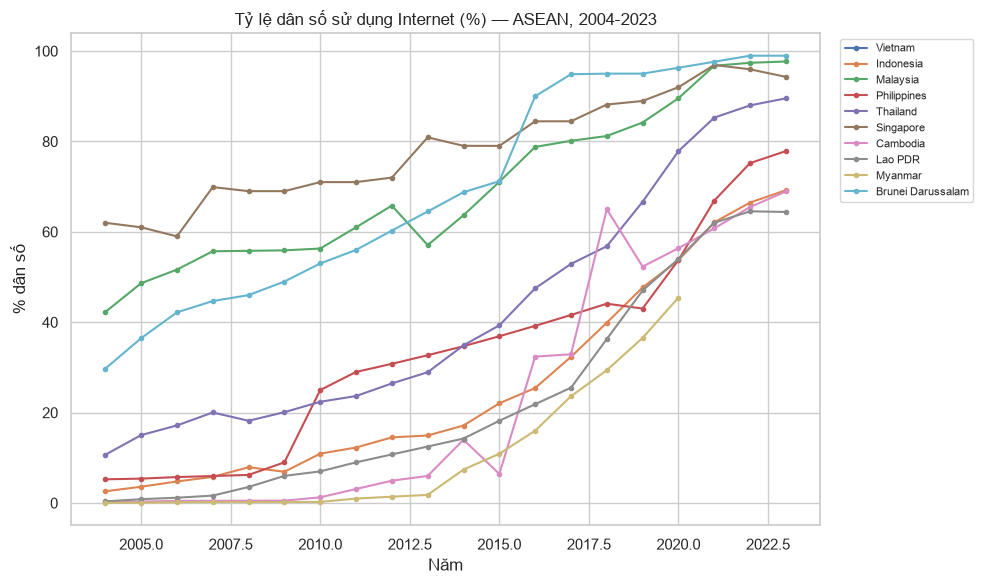

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
for country in ASEAN_COUNTRIES.values():
    sub = df_wide[df_wide["country"] == country].dropna(subset=["IT.NET.USER.ZS"])
    ax.plot(sub["year"], sub["IT.NET.USER.ZS"], marker="o", markersize=3, label=country)

ax.set_title("Tỷ lệ dân số sử dụng Internet (%) — ASEAN, 2004-2023")
ax.set_xlabel("Năm")
ax.set_ylabel("% dân số")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig("figures/01_internet_users_timeseries.png", dpi=150)
plt.show()


### Hình 2 — Tài chính toàn diện: tỷ lệ sở hữu tài khoản tài chính/mobile money (theo năm khảo sát Findex)

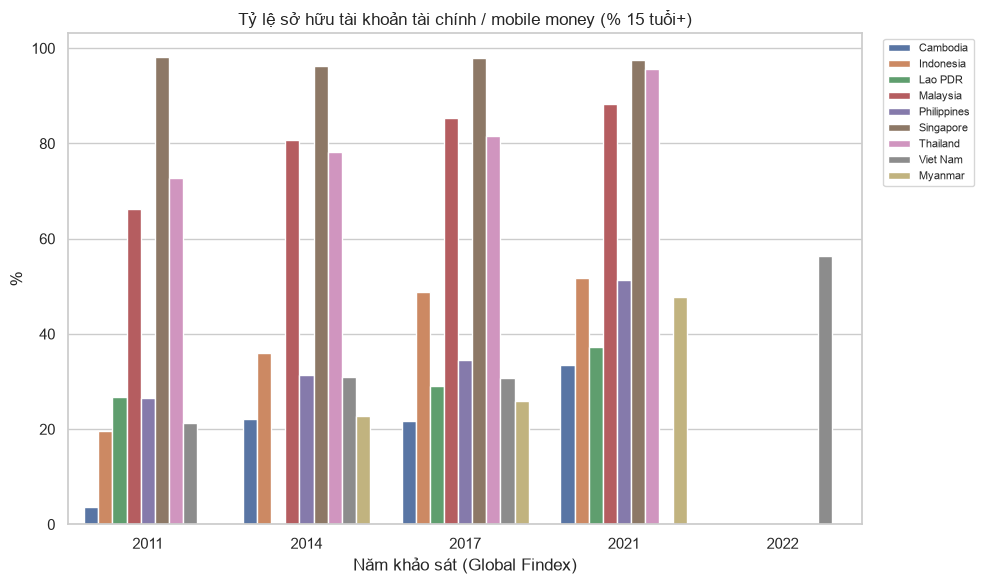

In [34]:
fx = df_wide.dropna(subset=["FX.OWN.TOTL.ZS"])[["country", "year", "FX.OWN.TOTL.ZS"]]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=fx, x="year", y="FX.OWN.TOTL.ZS", hue="country", ax=ax)
ax.set_title("Tỷ lệ sở hữu tài khoản tài chính / mobile money (% 15 tuổi+)")
ax.set_xlabel("Năm khảo sát (Global Findex)")
ax.set_ylabel("%")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig("figures/02_account_ownership.png", dpi=150)
plt.show()


### Hình 3 — Tương quan: Internet penetration vs. Gini index (mỗi điểm = 1 quốc gia-năm)

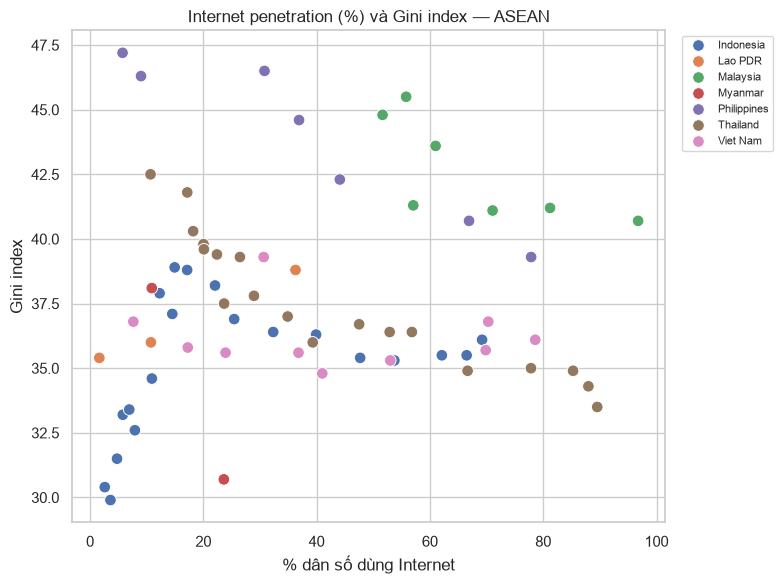

Hệ số tương quan Pearson (Internet% vs Gini): 0.056


In [35]:
scatter_df = df_wide.dropna(subset=["IT.NET.USER.ZS", "SI.POV.GINI"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=scatter_df, x="IT.NET.USER.ZS", y="SI.POV.GINI",
                 hue="country", s=70, ax=ax)
ax.set_title("Internet penetration (%) và Gini index — ASEAN")
ax.set_xlabel("% dân số dùng Internet")
ax.set_ylabel("Gini index")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig("figures/03_internet_vs_gini_scatter.png", dpi=150)
plt.show()

if len(scatter_df) > 2:
    corr = scatter_df["IT.NET.USER.ZS"].corr(scatter_df["SI.POV.GINI"])
    print(f"Hệ số tương quan Pearson (Internet% vs Gini): {corr:.3f}")


### Hình 4 — Mật độ chi nhánh ngân hàng truyền thống (năm gần nhất có số liệu, theo nước)

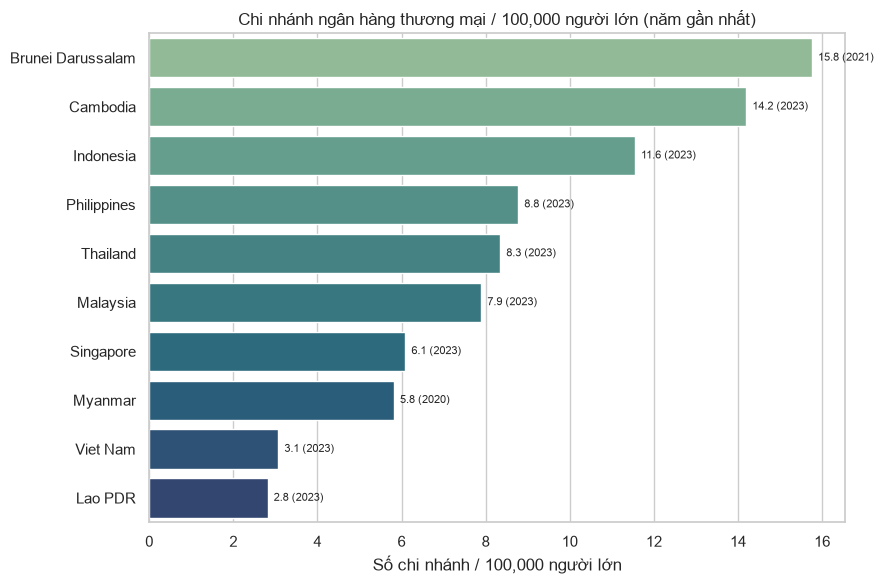

In [38]:
branch_latest = (
    df_clean[df_clean["indicator_code"] == "FB.CBK.BRCH.P5"]
    .sort_values("year")
    .groupby("country")
    .tail(1)
    .sort_values("value", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))

# Thêm hue="country" và legend=False để fix triệt để FutureWarning của Seaborn
sns.barplot(
    data=branch_latest,
    x="value",
    y="country",
    hue="country",
    legend=False,
    ax=ax,
    palette="crest"
)

ax.set_title("Chi nhánh ngân hàng thương mại / 100,000 người lớn (năm gần nhất)")
ax.set_xlabel("Số chi nhánh / 100,000 người lớn")
ax.set_ylabel("")

# Gắn nhãn giá trị và năm tương ứng vào đuôi mỗi cột
for i, row in enumerate(branch_latest.itertuples()):
    ax.text(row.value, i, f"  {row.value:.1f} ({int(row.year)})", va="center", fontsize=8)

fig.tight_layout()

# Tự động tạo thư mục figures nếu chưa có
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/04_bank_branches_latest.png", dpi=150)

plt.show()


### Hình 5 — Việt Nam: Tăng trưởng GDP đầu người vs. Gini index theo thời gian (2 trục)

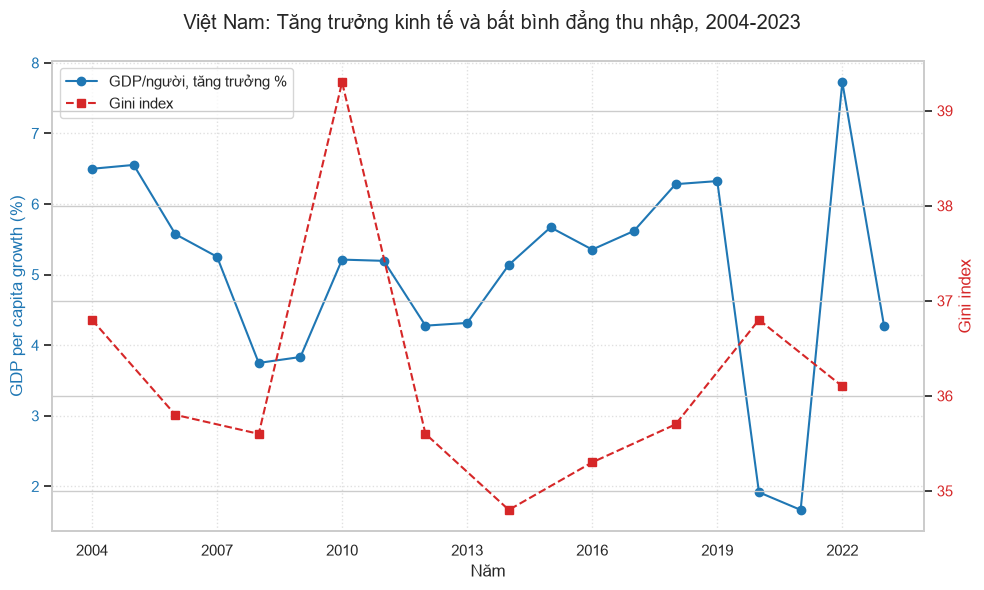

In [44]:
# 1. Lọc dữ liệu và ép kiểu năm về int
vn = df_wide[df_wide["country"].isin(["Vietnam", "Viet Nam"])].copy()
vn["year"] = vn["year"].astype(int)
vn = vn.sort_values("year")

fig, ax1 = plt.subplots(figsize=(10, 6))

# 2. Trục 1: Tăng trưởng GDP per capita
ax1.plot(
    vn["year"],
    vn["NY.GDP.PCAP.KD.ZG"],
    color="tab:blue",
    marker="o",
    label="GDP/người, tăng trưởng %"
)
ax1.set_xlabel("Năm")
ax1.set_ylabel("GDP per capita growth (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, linestyle=":", alpha=0.6)

# 3. Trục 2: Chỉ số Gini
ax2 = ax1.twinx()
gini_vn = vn.dropna(subset=["SI.POV.GINI"])
ax2.plot(
    gini_vn["year"],
    gini_vn["SI.POV.GINI"],
    color="tab:red",
    marker="s",
    linestyle="--",
    label="Gini index"
)
ax2.set_ylabel("Gini index", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# 4. Khóa trục X chỉ hiển thị số nguyên
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))

# 5. Gom chú thích (legend) từ cả 2 trục lên góc trên bên trái
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

fig.suptitle("Việt Nam: Tăng trưởng kinh tế và bất bình đẳng thu nhập, 2004-2023", y=0.98)
fig.tight_layout()

# 6. Lưu file và hiển thị
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/05_vietnam_growth_vs_gini.png", dpi=150)
plt.show()


### Hình 6 — Ma trận tương quan giữa 5 chỉ tiêu (toàn mẫu ASEAN)

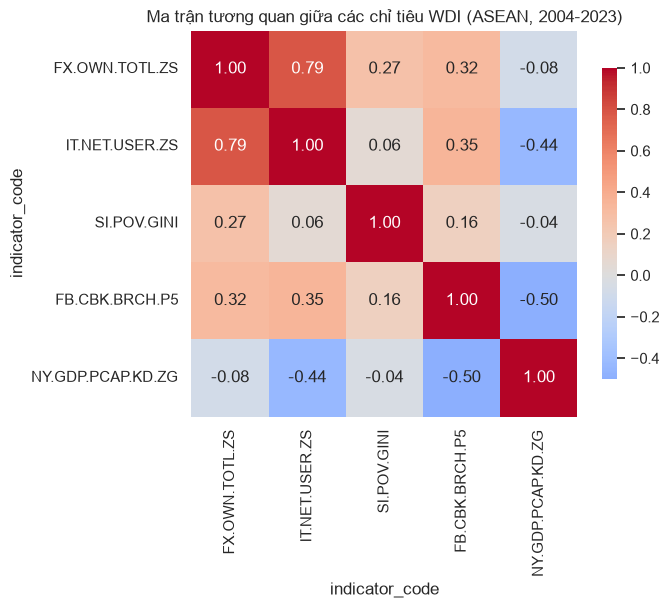

In [41]:
corr_matrix = df_wide[list(INDICATORS.keys())].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Ma trận tương quan giữa các chỉ tiêu WDI (ASEAN, 2004-2023)")
fig.tight_layout()
fig.savefig("figures/06_correlation_heatmap.png", dpi=150)
plt.show()


### Hình 7 (tùy chọn) — Bảng tổng hợp nhỏ (small multiples): xu hướng Internet% theo từng nước

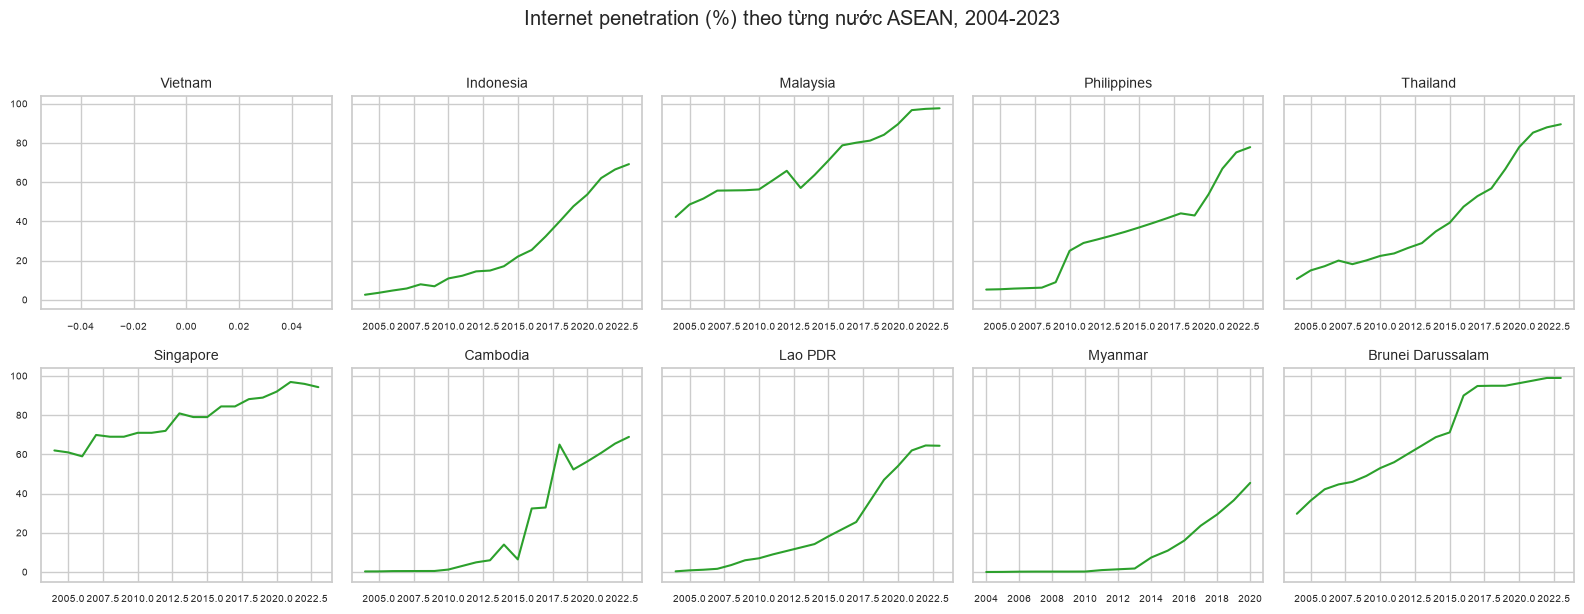

In [42]:
countries_list = list(ASEAN_COUNTRIES.values())
n_cols = 5
n_rows = int(np.ceil(len(countries_list) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows), sharey=True)
axes = axes.flatten()

for ax, country in zip(axes, countries_list):
    sub = df_wide[df_wide["country"] == country].dropna(subset=["IT.NET.USER.ZS"])
    ax.plot(sub["year"], sub["IT.NET.USER.ZS"], color="tab:green")
    ax.set_title(country, fontsize=10)
    ax.tick_params(labelsize=7)

for ax in axes[len(countries_list):]:
    ax.axis("off")

fig.suptitle("Internet penetration (%) theo từng nước ASEAN, 2004-2023", y=1.02)
fig.tight_layout()
fig.savefig("figures/07_small_multiples_internet.png", dpi=150, bbox_inches="tight")
plt.show()
